# Detect injections for cached discharges

Load cached `Discharge` objects from `data/discharges`, detect injections on
**channel 2** (energy window 6660 eV ±60 eV), store them in `discharge.injections`,
refresh `created_at` timestamps, and save each discharge back to its `.pkl`.

In [1]:
# Cell 1 — load all cached Discharge objects from data/discharges
from pathlib import Path

import pandas as pd

# Notebook lives in global_stats/, so step up one level to reach the repo root.
repo_root = Path.cwd().parent if Path.cwd().name == "global_stats" else Path.cwd()
discharges_dir = repo_root / "data" / "discharges"
cache_filename = "discharge_object.pkl"

# Map folder name -> loaded Discharge object (skip folders without a cache).
discharges = {}
for folder_path in sorted(p for p in discharges_dir.iterdir() if p.is_dir()):
    cache_file = folder_path / "cache" / cache_filename
    if not cache_file.exists():
        print(f"[SKIP] {folder_path.name}: no cache at {cache_file}")
        continue
    discharges[folder_path.name] = pd.read_pickle(cache_file)
    print(f"[LOADED] {folder_path.name}")

print(f"\nLoaded {len(discharges)} discharge(s).")

[LOADED] 2025-04-29--10-19
[LOADED] 2025-04-29--10-24
[LOADED] 2025-04-29--10-42
[LOADED] 2025-04-29--10-49
[LOADED] 2025-04-29--11-17
[LOADED] 2025-04-29--11-19
[LOADED] 2025-04-29--11-23
[LOADED] 2025-04-29--11-32
[LOADED] 2025-04-29--11-37
[LOADED] 2025-04-29--12-14
[LOADED] 2025-04-29--12-28
[LOADED] 2025-04-29--12-50
[LOADED] 2025-04-29--12-58
[LOADED] 2025-04-29--13-17
[LOADED] 2025-04-29--13-51
[LOADED] test

Loaded 16 discharge(s).


In [2]:
# Cell 2 — detect injections on channel 2 and store them in discharge.injections
from datetime import datetime

from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections, InjectionDetectionConfig

# Detection settings: Fe XXV line at 6660 eV, ±60 eV window (pipeline defaults).
LINE_ENERGY_eV = 6660.0
HALF_WIDTH_eV = 60.0
DETECT_CHANNEL = 2
detection_config = InjectionDetectionConfig()  # default parameters

detect_rows = []
for folder_name, discharge in discharges.items():
    # Some discharges may not have channel 2 — record and skip those.
    if DETECT_CHANNEL not in discharge.channels:
        print(f"[SKIP] {folder_name}: no channel {DETECT_CHANNEL}")
        detect_rows.append({"folder": folder_name, "n_injections": None,
                            "error": f"no channel {DETECT_CHANNEL}"})
        continue

    # Build the per-channel time trace, then run injection detection on it.
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)
    injections = detect_injections(trace, LINE_ENERGY_eV, detection_config)

    # Stamp a fresh detection time on every injection for cache provenance.
    now = datetime.now()
    for inj in injections:
        inj.created_at = now

    # Attach injections to the discharge and refresh its own timestamp too.
    discharge.injections = injections
    discharge.created_at = now

    print(f"[OK] {folder_name}: {len(injections)} injection(s)")
    detect_rows.append({"folder": folder_name, "n_injections": len(injections),
                        "error": ""})

print("\nDetection summary:")
print(pd.DataFrame(detect_rows).to_string(index=False))

[OK] 2025-04-29--10-19: 4 injection(s)
[OK] 2025-04-29--10-24: 4 injection(s)
[OK] 2025-04-29--10-42: 1 injection(s)
[OK] 2025-04-29--10-49: 1 injection(s)
[OK] 2025-04-29--11-17: 3 injection(s)
[OK] 2025-04-29--11-19: 5 injection(s)
[OK] 2025-04-29--11-23: 3 injection(s)
[OK] 2025-04-29--11-32: 3 injection(s)
[OK] 2025-04-29--11-37: 1 injection(s)
[OK] 2025-04-29--12-14: 3 injection(s)
[OK] 2025-04-29--12-28: 5 injection(s)
[OK] 2025-04-29--12-50: 2 injection(s)
[OK] 2025-04-29--12-58: 4 injection(s)
[OK] 2025-04-29--13-17: 2 injection(s)
[OK] 2025-04-29--13-51: 5 injection(s)
[OK] test: 5 injection(s)

Detection summary:
           folder  n_injections error
2025-04-29--10-19             4      
2025-04-29--10-24             4      
2025-04-29--10-42             1      
2025-04-29--10-49             1      
2025-04-29--11-17             3      
2025-04-29--11-19             5      
2025-04-29--11-23             3      
2025-04-29--11-32             3      
2025-04-29--11-37          

In [3]:
# Cell 3 — save updated discharges back to their .pkl cache files
save_rows = []
for folder_name, discharge in discharges.items():
    cache_file = discharges_dir / folder_name / "cache" / cache_filename
    try:
        # Overwrite the same cache file with the updated discharge (now carrying
        # detected injections and refreshed timestamps).
        pd.to_pickle(discharge, cache_file)
        n_inj = len(discharge.injections) if discharge.injections is not None else 0
        print(f"[SAVED] {folder_name}: {n_inj} injection(s) -> {cache_file}")
        save_rows.append({"folder": folder_name, "status": "saved",
                          "n_injections": n_inj, "error": ""})
    except Exception as exc:
        print(f"[FAILED] {folder_name}: {exc}")
        save_rows.append({"folder": folder_name, "status": "failed",
                          "n_injections": None, "error": str(exc)})

print("\nSave summary:")
print(pd.DataFrame(save_rows).to_string(index=False))

[SAVED] 2025-04-29--10-19: 4 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-19\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-24: 4 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-24\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-42: 1 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-42\cache\discharge_object.pkl
[SAVED] 2025-04-29--10-49: 1 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-49\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-17: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-17\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-19: 5 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-19\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-23: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-23\cache\discharge_object.pkl
[SAVED] 2025-04-29--11-32: 3 injection(s) -> d:\ℱ Sci\IFPiLM\1st task\data\discharg

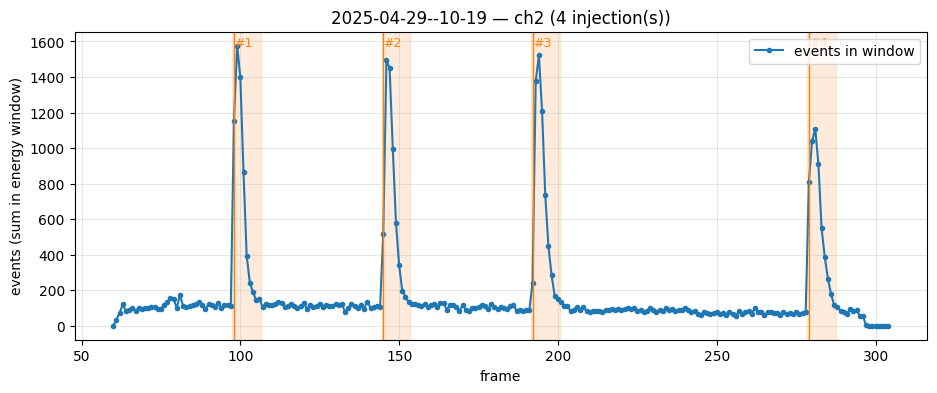

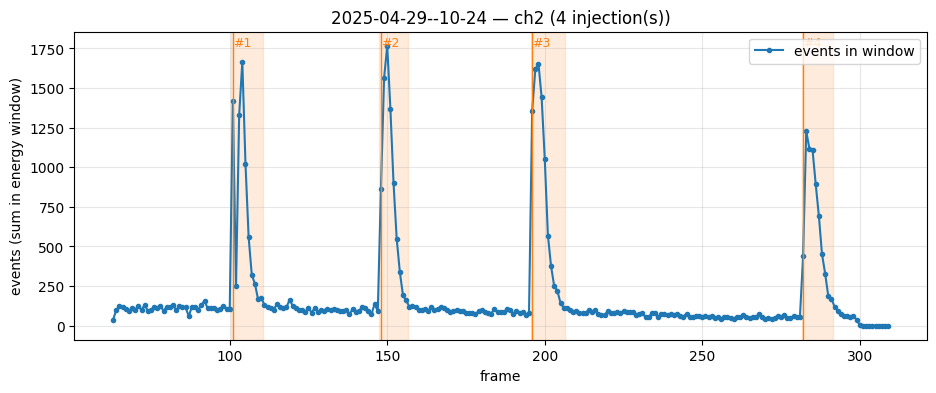

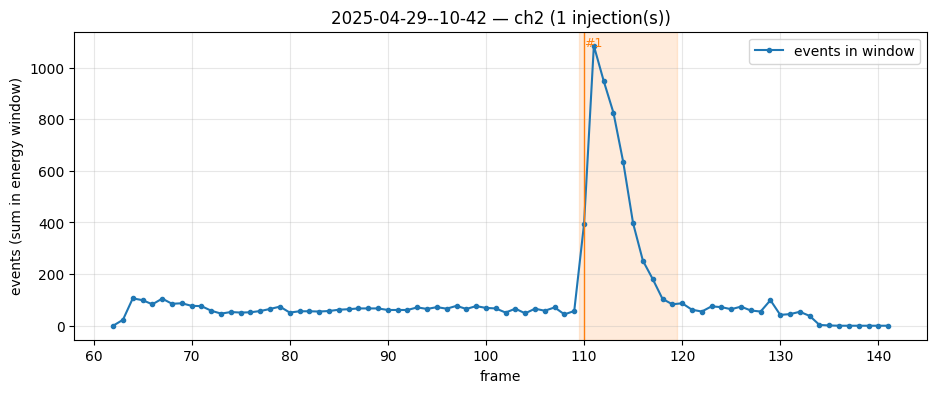

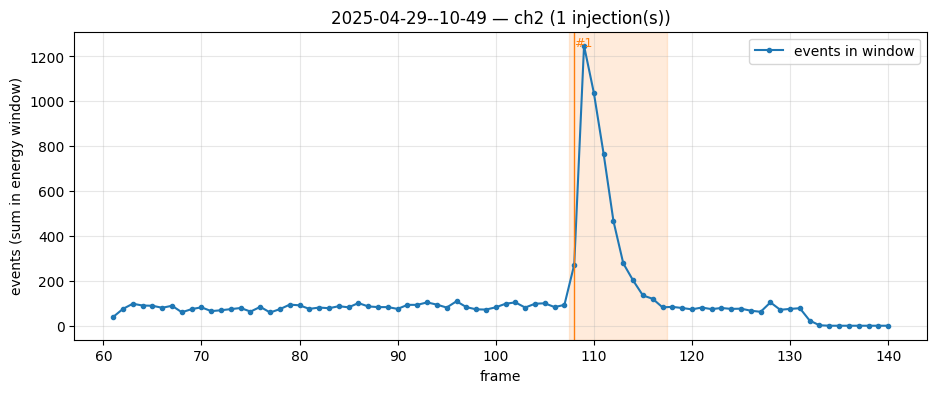

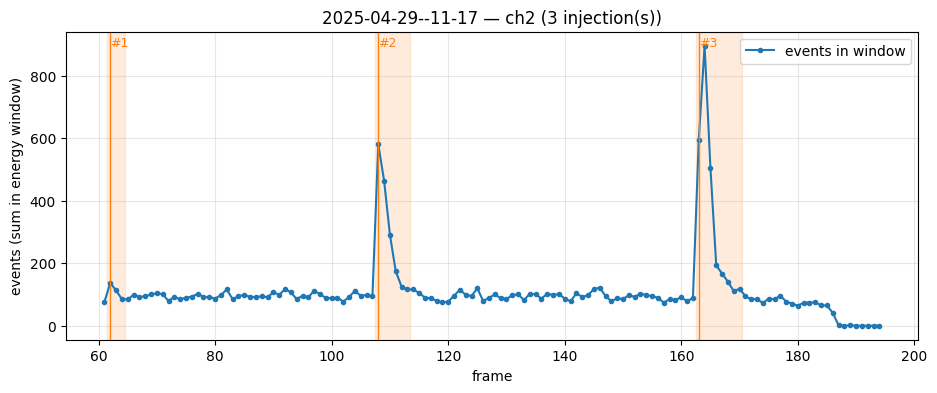

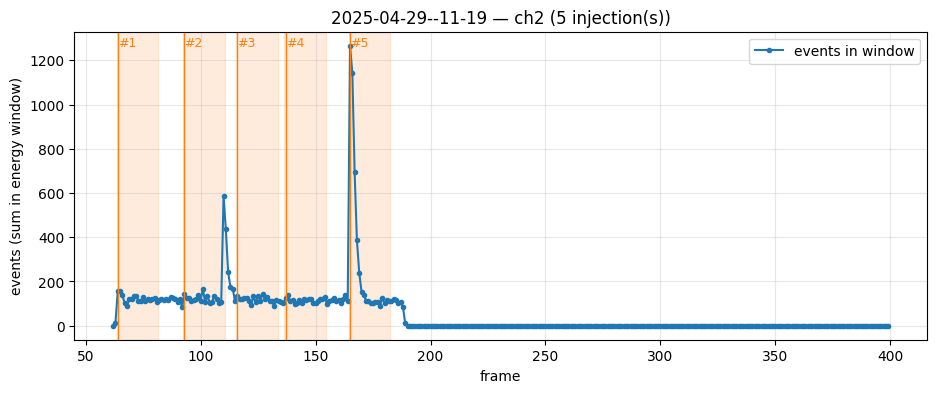

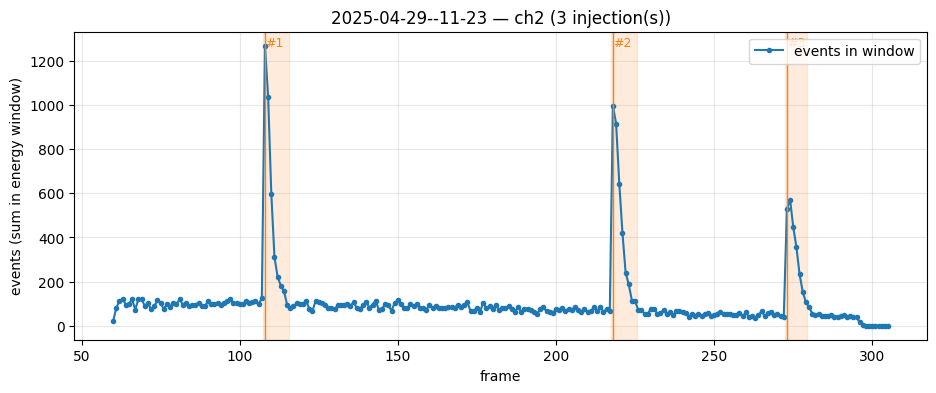

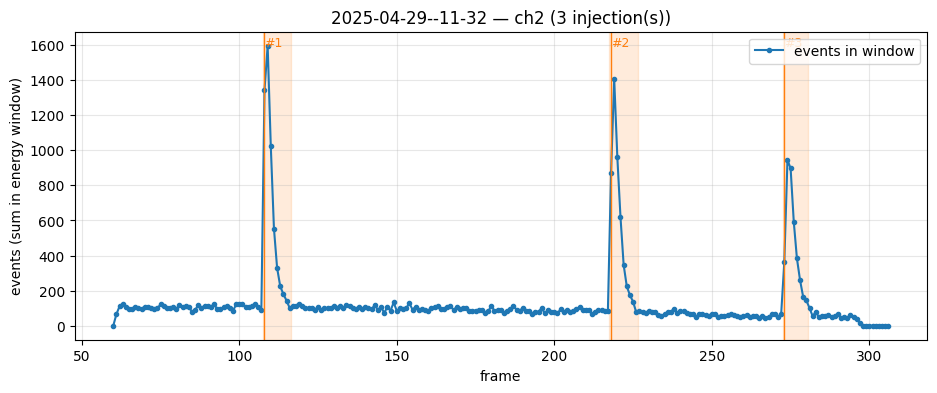

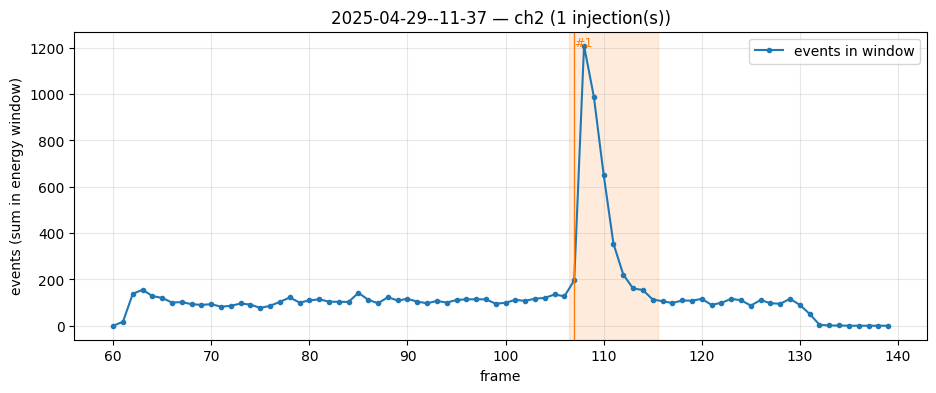

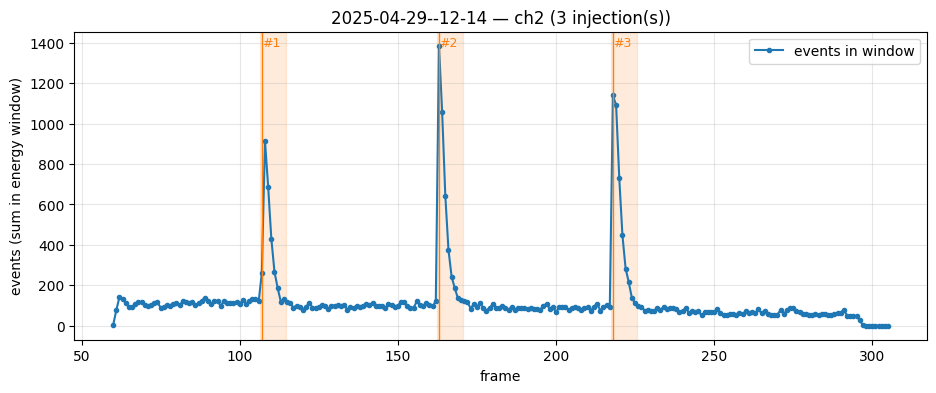

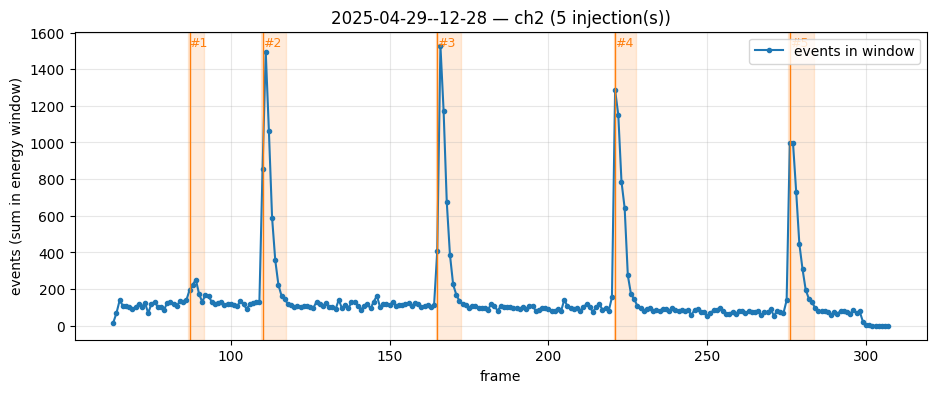

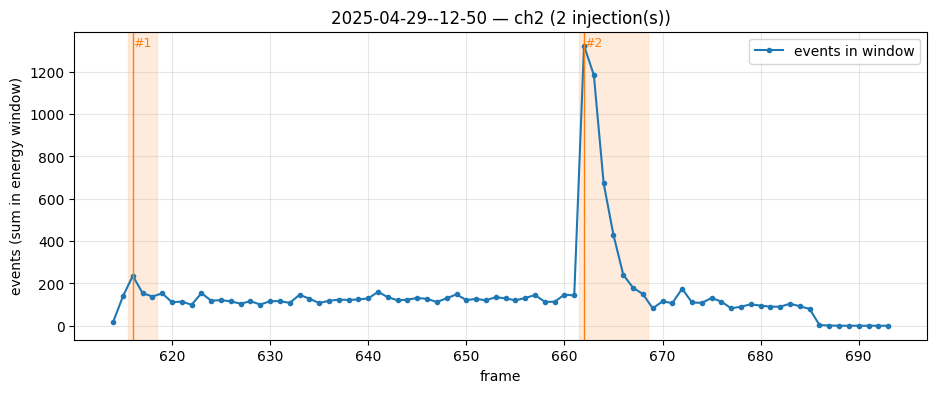

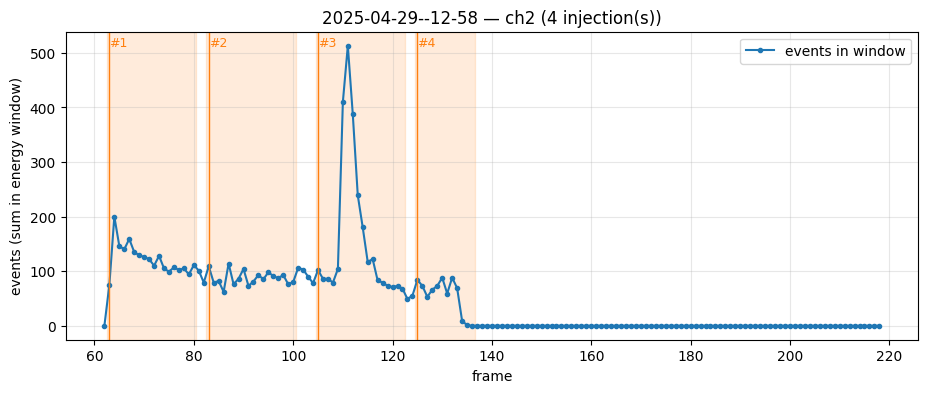

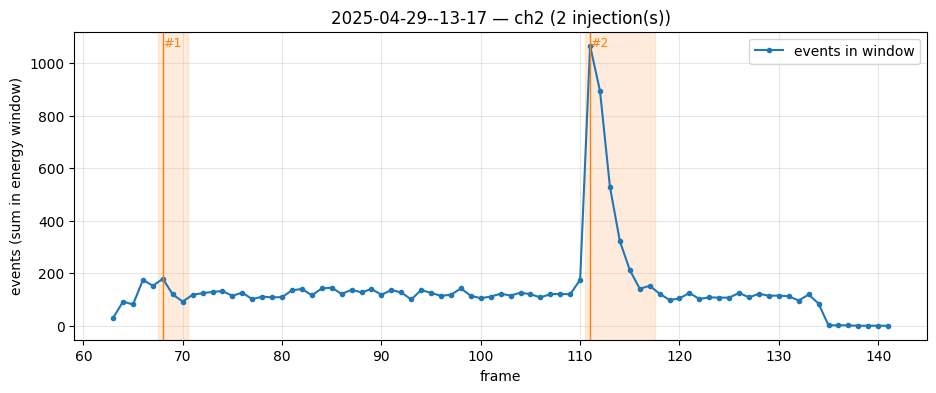

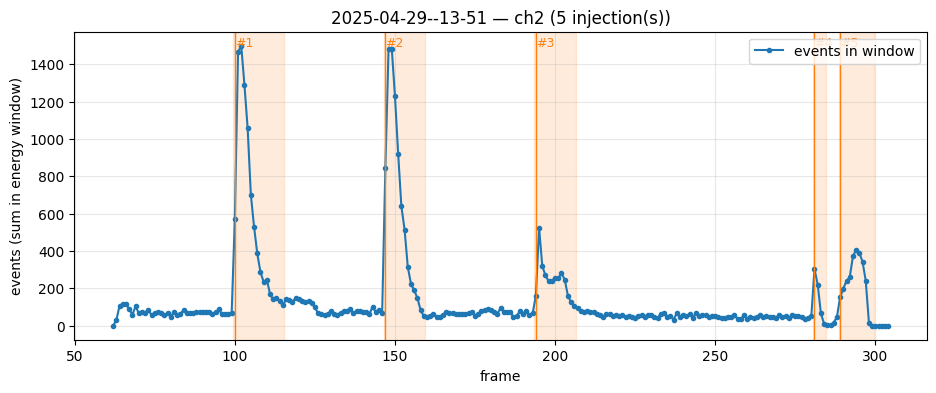

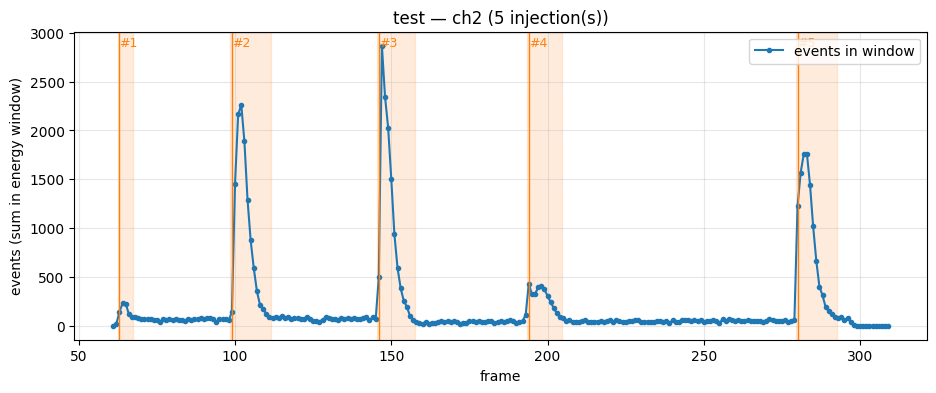

In [ ]:
# Cell 4 — plot each discharge's channel-2 timetrace with marked injections
import matplotlib.pyplot as plt

from pha_lib.plotting import plot_timetrace_with_injections
from pha_lib.discharges import _robust_background_and_scale

for folder_name, discharge in discharges.items():
    # Only channel 2 was analyzed, so skip discharges without it.
    if DETECT_CHANNEL not in discharge.channels:
        continue

    # Rebuild the same trace used for detection (no cache needed, in-memory).
    channel = discharge.channels[DETECT_CHANNEL]
    trace = integrate_energy_window(channel, LINE_ENERGY_eV, HALF_WIDTH_eV)

    # Recompute the detection threshold exactly as detect_injections does:
    # robust background + threshold_factor * robust noise scale.
    bg, scale = _robust_background_and_scale(trace.values)
    thr = bg + detection_config.threshold_factor * scale

    # Injections detected in Cell 2 (empty list if none / not yet run).
    injections = discharge.injections or []

    # One figure per discharge; reuse the library plotting helper.
    fig, ax = plt.subplots(figsize=(11, 4))
    plot_timetrace_with_injections(
        trace,
        injections,
        ax=ax,
        title=f"{folder_name} — ch{DETECT_CHANNEL} "
              f"({len(injections)} injection(s))",
    )

    # Draw the detection threshold as a dashed red line.
    ax.axhline(thr, color="tab:red", ls="--", lw=1, label=f"threshold={thr:.1f}")
    ax.legend(loc="upper right")

    plt.show()